In [77]:
import pandas as pd
financial_df = pd.read_csv('/Users/alecxszhang/Desktop/Stat 359/data/Financial_tweets.csv')
politics_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/politics_sentiment.csv")
videogames_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/videogames_train.csv")
nfl_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/nfl_sentiments.csv")
none_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/none_sentiment.csv")


In [78]:
def classify_sentiment(score):
    if score < -0.1:
        return 'negative'
    elif score > 0.1:
        return 'positive'
    else:
        return 'neutral'

financial_df['sentiment'] = financial_df['score'].apply(classify_sentiment)
financial_df['domain'] = 'financial'
financial_df = financial_df.rename(columns={'full_text': 'text'})
from sklearn.model_selection import train_test_split

train_fin_df, test_fin_df = train_test_split(
    financial_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=financial_df['sentiment']
)


In [79]:
videogames_df['sentiment'] = videogames_df['sentiment'].str.lower()
videogames_df['domain'] = 'videogames'
train_vg_df, test_vg_df = train_test_split(
    videogames_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=videogames_df['sentiment']
)



In [80]:
print(politics_df['sentiment'].value_counts(dropna=False))
print(politics_df['sentiment'].dtype)

sentiment
0.0    2475
1.0    2420
2.0     556
NaN       3
Name: count, dtype: int64
float64


In [81]:
politics_df['domain'] = 'politics'
politics_df = politics_df.rename(columns={'tweet': 'text'})
politics_df['sentiment'] = politics_df['sentiment'].map({0: 'negative', 1: 'positive', 2: 'neutral'})
politics_df = politics_df.dropna(subset=['sentiment'])

train_pol_df, test_pol_df = train_test_split(
    politics_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=politics_df['sentiment']
)



In [82]:
none_df["domain"] = "none"
none_df = none_df.rename(columns={'tweet': 'text'})
none_df['sentiment'] = none_df['sentiment'].map({0: 'negative', 1: 'positive', 2: 'neutral'})
none_df = none_df.dropna(subset=['sentiment'])

train_none_df, test_none_df = train_test_split(
    none_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=none_df['sentiment']
)



In [83]:

nfl_df['domain'] = 'nfl'

#filter to only tweets that mention NFL-related keywords
# to remove off-topic scraped content
import re
nfl_keywords = r'\b(nfl|football|touchdown|quarterback|qb|mahomes|brady|receiver|linebacker|' \
               r'packers|chiefs|eagles|cowboys|49ers|ravens|browns|patriots|bills|' \
               r'draft|super bowl|playoffs|offense|defense|interception|fumble|yard|'\
               r'rushing|passing|receiver|tight end|kicker)\b'

nfl_df = nfl_df[nfl_df['text'].str.contains(nfl_keywords, case=False, regex=True)]
nfl_df = nfl_df[nfl_df['sentiment'].isin(['negative', 'positive', 'neutral'])]

train_nfl_df, test_nfl_df = train_test_split(
    nfl_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=nfl_df['sentiment']
)


/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_4291/3316467085.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  nfl_df = nfl_df[nfl_df['text'].str.contains(nfl_keywords, case=False, regex=True)]


In [84]:
combined_df = pd.concat([
    train_vg_df[['text', 'sentiment', 'domain']],
    train_pol_df[['text', 'sentiment', 'domain']],
    train_fin_df[['text', 'sentiment', 'domain']],
    train_nfl_df[['text', 'sentiment', 'domain']],
    train_none_df[['text', 'sentiment', 'domain']]
    
], ignore_index=True)


combined_df.head()

,text,sentiment,domain
0,I MISS HIM ALREADY,positive,videogames
1,Although I might actually actually try out fab...,positive,videogames
2,Why,neutral,videogames
3,I decided to hop back into the Battlefield Har...,positive,videogames
4,Shit pic.twitter.com / ra0gwVDlt3,negative,videogames


In [85]:
min_count = combined_df['domain'].value_counts().min()
print(f"Balancing to {min_count} rows per domain")

combined_df = combined_df.groupby('domain').apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)

print(combined_df['domain'].value_counts())

none_samples = none_df.sample(min_count, random_state=42)[['text', 'sentiment']].copy()
none_samples['domain'] = 'none'

# sentiment140 uses 0 and 4, remap to negative/positive
none_samples['sentiment'] = none_samples['sentiment'].map({0: 'negative', 4: 'positive'})

combined_df = pd.concat([
    combined_df,
    none_samples
], ignore_index=True)

combined_df['domain'].value_counts()

Balancing to 2252 rows per domain
domain
financial     2252
nfl           2252
none          2252
politics      2252
videogames    2252
Name: count, dtype: int64


/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_4291/1011788511.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df = combined_df.groupby('domain').apply(


domain
none          4504
financial     2252
nfl           2252
politics      2252
videogames    2252
Name: count, dtype: int64

In [86]:
combined_df.to_csv('/Users/alecxszhang/Desktop/Stat 359/data/combined_df.csv', index=False)

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import evaluate

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# ── Label mappings ─────────────────────────────────────────────────────────────
domain2id    = {'nfl': 0, 'financial': 1, 'politics': 2, 'videogames': 3, 'none': 4}
id2domain    = {v: k for k, v in domain2id.items()}
sentiment2id = {'negative': 0, 'positive': 1, "neutral" : 2}
id2sentiment = {v: k for k, v in sentiment2id.items()}

# ── Prep dataframe ─────────────────────────────────────────────────────────────
# If using Sentiment140 (0 = negative, 4 = positive), remap first:
# combined_df['sentiment'] = combined_df['sentiment'].map({0: 'negative', 4: 'positive'})

combined_df['domain_label']    = combined_df['domain'].map(domain2id)
combined_df['sentiment_label'] = combined_df['sentiment'].map(sentiment2id)
combined_df = combined_df.dropna(subset=['text', 'domain_label', 'sentiment_label'])
combined_df['text']            = combined_df['text'].astype(str)
combined_df['domain_label']    = combined_df['domain_label'].astype(int)
combined_df['sentiment_label'] = combined_df['sentiment_label'].astype(int)

train_df, val_df = train_test_split(
    combined_df[['text', 'domain_label', 'sentiment_label']],
    test_size=0.2,
    random_state=42,
    stratify=combined_df['domain_label']
)

# ── Tokenizer & datasets ───────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(examples):
    tokens = tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)
    tokens['labels']           = examples['domain_label']
    tokens['sentiment_labels'] = examples['sentiment_label']
    return tokens

train_ds = Dataset.from_pandas(train_df).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df).map(tokenize, batched=True)

# ── Multi-task model ───────────────────────────────────────────────────────────
class MultiTaskModel(nn.Module):
    def __init__(self, backbone, num_domains, num_sentiments, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        hidden = backbone.config.hidden_size

        self.domain_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_domains)
        )
        self.sentiment_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_sentiments)
        )

    def forward(self, input_ids, attention_mask, labels=None, sentiment_labels=None):
        outputs   = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = outputs.last_hidden_state[:, 0, :]

        domain_logits    = self.domain_head(cls_token)
        sentiment_logits = self.sentiment_head(cls_token)

        loss = None
        if labels is not None and sentiment_labels is not None:
            domain_loss    = F.cross_entropy(domain_logits, labels)
            sentiment_loss = F.cross_entropy(sentiment_logits, sentiment_labels)
            loss           = domain_loss + sentiment_loss

        return {
            'loss':             loss,
            'domain_logits':    domain_logits,
            'sentiment_logits': sentiment_logits,
        }

backbone = AutoModel.from_pretrained('distilbert-base-uncased')
model    = MultiTaskModel(backbone, num_domains=5, num_sentiments=3).to(device)

# ── Custom Trainer ─────────────────────────────────────────────────────────────
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss    = outputs['loss']
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        with torch.no_grad():
            outputs = model(**inputs)

        loss   = outputs['loss']
        logits = (outputs['domain_logits'], outputs['sentiment_logits'])
        labels = (inputs.get('labels'), inputs.get('sentiment_labels'))
        return loss, logits, labels

def compute_metrics(eval_pred):
    (domain_logits, sentiment_logits), (domain_labels, sentiment_labels) = eval_pred

    domain_preds    = np.argmax(domain_logits,    axis=-1)
    sentiment_preds = np.argmax(sentiment_logits, axis=-1)

    domain_acc    = (domain_preds    == domain_labels).mean()
    sentiment_acc = (sentiment_preds == sentiment_labels).mean()

    return {
        'domain_accuracy':    round(domain_acc, 4),
        'sentiment_accuracy': round(sentiment_acc, 4),
    }

# ── Training ───────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./multitask-classifier',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='domain_accuracy',
    report_to='none',
    logging_steps=10,
    fp16=torch.cuda.is_available(),
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

# ── Save ───────────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), './multitask-classifier/model_weights.pt')
tokenizer.save_pretrained('./multitask-classifier')
print("Saved to ./multitask-classifier")

Using device: mps


Map:   0%|          | 0/9008 [00:00<?, ? examples/s]

Map:   0%|          | 0/2252 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Domain Accuracy,Sentiment Accuracy
1,0.779200,0.763611,0.963600,0.728700
2,0.577900,0.762629,0.966700,0.743300
3,0.260400,0.873542,0.967100,0.739800


Saved to ./multitask-classifier


In [88]:
print(combined_df['domain'].value_counts())
print(combined_df['domain'].unique())
print(combined_df['domain_label'].isna().sum())    
print(combined_df['domain_label'].value_counts())  

domain
financial     2252
nfl           2252
none          2252
politics      2252
videogames    2252
Name: count, dtype: int64
['financial' 'nfl' 'none' 'politics' 'videogames']
0
domain_label
1    2252
0    2252
4    2252
2    2252
3    2252
Name: count, dtype: int64


In [89]:
import torch.nn.functional as F

THRESHOLD = 0.15

def predict(texts, threshold=THRESHOLD):
    if isinstance(texts, str):
        texts = [texts]

    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    results = []
    for i in range(len(texts)):
        domain_probs    = F.softmax(outputs['domain_logits'][i],    dim=-1)
        sentiment_probs = F.softmax(outputs['sentiment_logits'][i], dim=-1)

        domains = [id2domain[j] for j, p in enumerate(domain_probs) if p.item() > threshold] or ['unknown']

        results.append({
            'domains':         domains,
            'domain_scores':   {id2domain[j]: round(p.item(), 3) for j, p in enumerate(domain_probs)},
            'sentiment':       id2sentiment[sentiment_probs.argmax().item()],
            'sentiment_score': round(sentiment_probs.max().item(), 3),
        })

    return results

test_tweets = [
    "The NFL player just signed a huge financial deal",
    "Mahomes tore his ACL",
    "NASDAQ dropped 3.5 points today",
    "I just had a great lunch today",
    "Congress passes new bill on healthcare reform",
]

for tweet, pred in zip(test_tweets, predict(test_tweets)):
    print(f"Tweet:     {tweet}")
    print(f"Domains:   {pred['domains']}")
    print(f"Sentiment: {pred['sentiment']} ({pred['sentiment_score']})")
    print(f"Scores:    {pred['domain_scores']}\n")

Tweet:     The NFL player just signed a huge financial deal
Domains:   ['nfl']
Sentiment: neutral (0.739)
Scores:    {'nfl': 0.995, 'financial': 0.001, 'politics': 0.001, 'videogames': 0.003, 'none': 0.0}

Tweet:     Mahomes tore his ACL
Domains:   ['none']
Sentiment: negative (0.999)
Scores:    {'nfl': 0.082, 'financial': 0.011, 'politics': 0.018, 'videogames': 0.05, 'none': 0.84}

Tweet:     NASDAQ dropped 3.5 points today
Domains:   ['financial', 'none']
Sentiment: negative (0.945)
Scores:    {'nfl': 0.013, 'financial': 0.443, 'politics': 0.016, 'videogames': 0.104, 'none': 0.424}

Tweet:     I just had a great lunch today
Domains:   ['none']
Sentiment: positive (0.949)
Scores:    {'nfl': 0.0, 'financial': 0.0, 'politics': 0.001, 'videogames': 0.001, 'none': 0.998}

Tweet:     Congress passes new bill on healthcare reform
Domains:   ['politics']
Sentiment: neutral (0.967)
Scores:    {'nfl': 0.011, 'financial': 0.002, 'politics': 0.982, 'videogames': 0.003, 'none': 0.002}



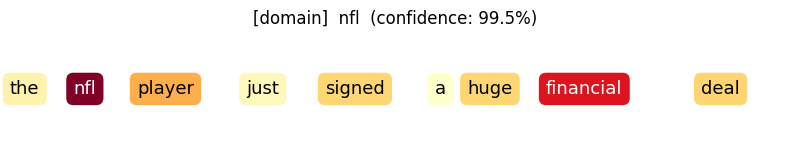

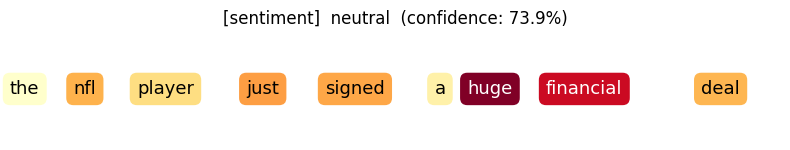

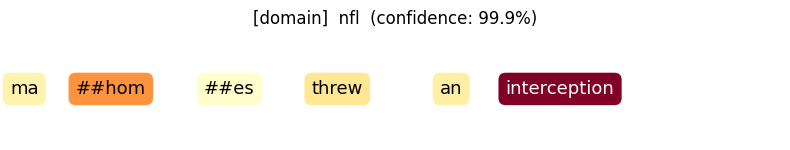

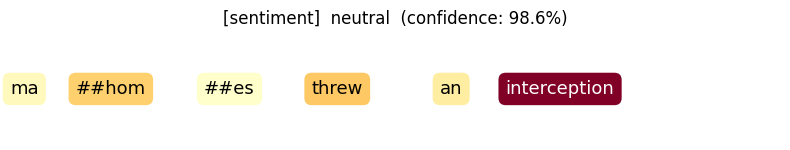

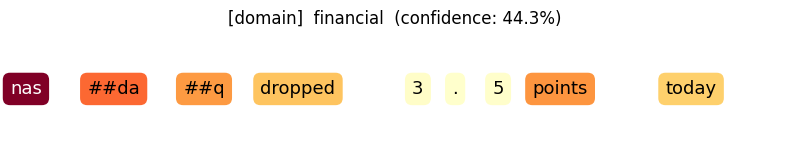

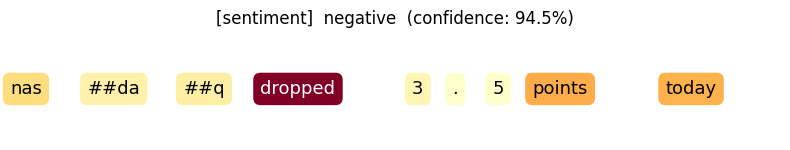

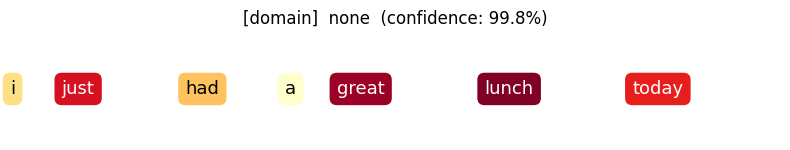

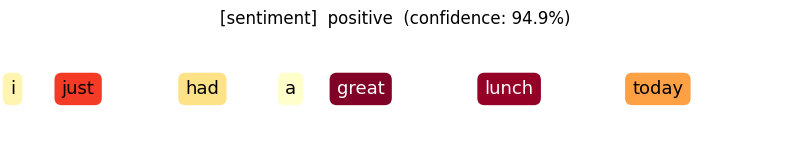

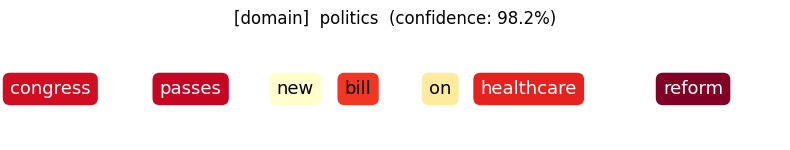

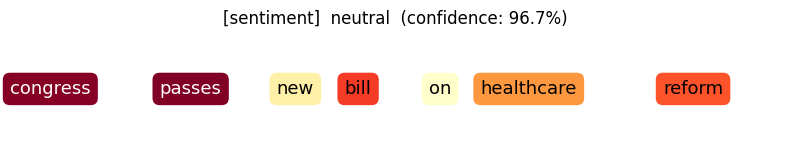

In [90]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def get_saliency(text, model, tokenizer, device, task='domain'):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    embedding_layer = model.backbone.embeddings
    captured = {}

    def forward_hook(module, input, output):
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output

    handle = embedding_layer.register_forward_hook(forward_hook)
    outputs = model(**inputs)
    handle.remove()

    if task == 'domain':
        logits         = outputs['domain_logits']
        predicted_class = logits.argmax(dim=-1).item()
        label          = id2domain[predicted_class]
    else:
        logits         = outputs['sentiment_logits']
        predicted_class = logits.argmax(dim=-1).item()
        label          = id2sentiment[predicted_class]

    logits[0, predicted_class].backward()

    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens   = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    score    = torch.softmax(logits, dim=-1)[0, predicted_class].item()

    return tokens, saliency, label, score


def plot_saliency(text, model, tokenizer, device, task='domain'):
    tokens, saliency, label, score = get_saliency(text, model, tokenizer, device, task)

    tokens   = tokens[1:-1]
    saliency = saliency[1:-1]
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.6))
    ax.axis('off')

    cmap = plt.get_cmap("YlOrRd")
    x = 0
    for token, sal in zip(tokens, saliency):
        color = cmap(sal)
        ax.text(x, 0.5, token, ha='left', va='center', fontsize=13,
                bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                color='black' if sal < 0.7 else 'white')
        x += len(token) * 0.13 + 0.15

    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.set_title(f'[{task}]  {label}  (confidence: {score:.1%})', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


test_tweets = [
    "The NFL player just signed a huge financial deal",
    "Mahomes threw an interception",
    "NASDAQ dropped 3.5 points today",
    "I just had a great lunch today",
    "Congress passes new bill on healthcare reform"
]

for tweet in test_tweets:
    plot_saliency(tweet, model, tokenizer, device, task='domain')
    plot_saliency(tweet, model, tokenizer, device, task='sentiment')

/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_4291/2441124508.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = combined_df.groupby('domain').apply(


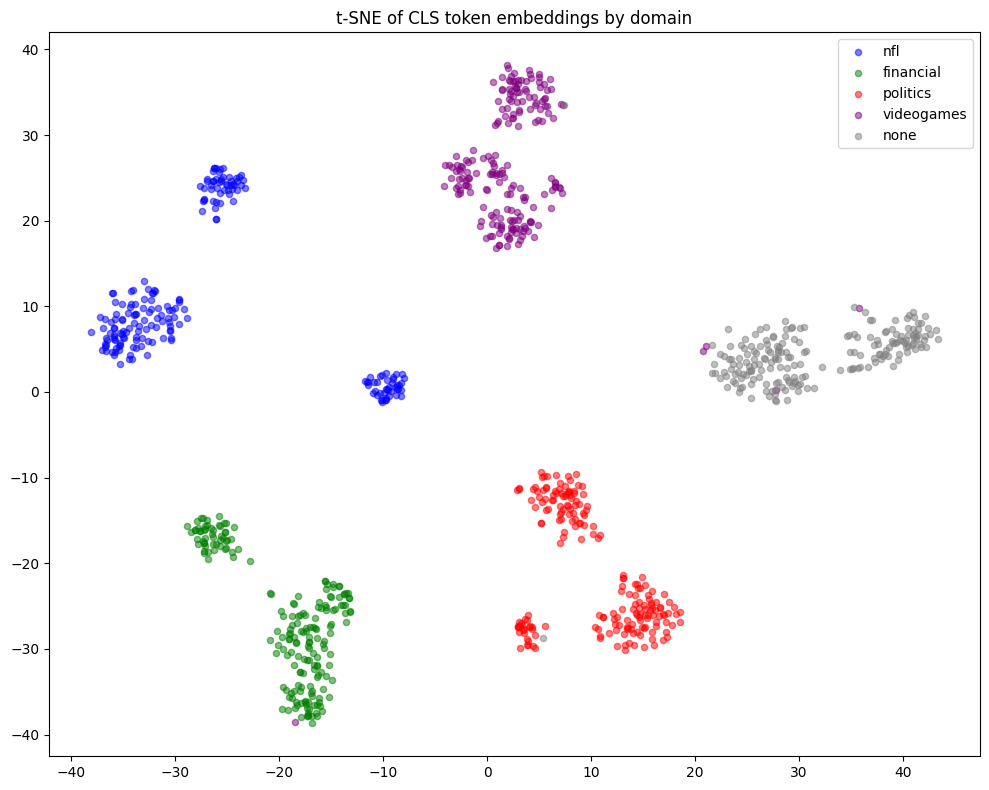

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_cls_embeddings(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True, 
                          truncation=True, max_length=128).to(device)
        
        with torch.no_grad():
            outputs = model.backbone(**inputs)  # was model.distilbert
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

sample_size = 200
sample_df = combined_df.groupby('domain').apply(
    lambda x: x.sample(min(sample_size, len(x)), random_state=42)
).reset_index(drop=True)

texts  = sample_df['text'].tolist()
labels = sample_df['domain'].tolist()

embeddings = get_cls_embeddings(texts, model, tokenizer, device)

tsne    = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(embeddings)

domain_colors = {
    'nfl':        'blue',
    'financial':  'green',
    'politics':   'red',
    'videogames': 'purple',
    'none':       'gray'
}

plt.figure(figsize=(10, 8))
for domain, color in domain_colors.items():
    mask = [l == domain for l in labels]
    pts  = reduced[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, label=domain, alpha=0.5, s=20)

plt.legend()
plt.title('t-SNE of CLS token embeddings by domain')
plt.tight_layout()
plt.show()

/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_4291/1203115143.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = combined_df.groupby('domain').apply(


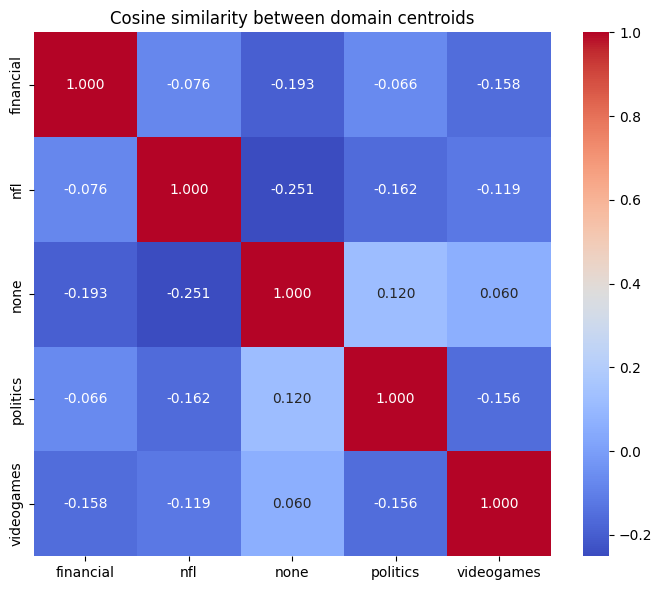

In [92]:
from sklearn.metrics.pairwise import cosine_similarity

# need these if the t-SNE cell hasn't been run
sample_size = 200
sample_df = combined_df.groupby('domain').apply(
    lambda x: x.sample(min(sample_size, len(x)), random_state=42)
).reset_index(drop=True)

texts  = sample_df['text'].tolist()
labels = sample_df['domain'].tolist()

embeddings = get_cls_embeddings(texts, model, tokenizer, device)

# Compute mean embedding per domain (the "class centroid")
domain_centroids = {}
for domain in combined_df['domain'].unique():
    mask = [l == domain for l in labels]
    domain_centroids[domain] = embeddings[mask].mean(axis=0)

# Cosine similarity matrix
domains         = list(domain_centroids.keys())
centroid_matrix = np.vstack([domain_centroids[d] for d in domains])
sim_matrix      = cosine_similarity(centroid_matrix)

# Plot as heatmap
import seaborn as sns
plt.figure(figsize=(7, 6))
sns.heatmap(sim_matrix, xticklabels=domains, yticklabels=domains,
            annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Cosine similarity between domain centroids')
plt.tight_layout()
plt.show()


Processing 'interception'...
  'interception' tokenizes as: ['interception'], matching on root: 'interception'

Processing 'market'...
  'market' tokenizes as: ['market'], matching on root: 'market'

Processing 'draft'...
  'draft' tokenizes as: ['draft'], matching on root: 'draft'
    Tokens were: ['[CLS]', 'congress', 'drafted', 'a', 'new', 'healthcare', 'bill', '[SEP]']
    Tokens were: ['[CLS]', 'the', 'game', 'developer', 'drafted', 'new', 'patch', 'notes', '[SEP]']

Processing 'trade'...
  'trade' tokenizes as: ['trade'], matching on root: 'trade'
    Tokens were: ['[CLS]', 'the', 'madden', 'player', 'traded', 'his', 'star', 'quarterback', 'in', 'franchise', 'mode', '[SEP]']

=== Cosine similarity: same word, different contexts ===

  'interception' tokenizes as: ['interception'], matching on root: 'interception'
'interception':
  0.966  |  'Mahomes threw an interception in the fourth q' vs 'The cornerback made an interception at the go'  ✓ same domain
  0.860  |  'Mahomes threw

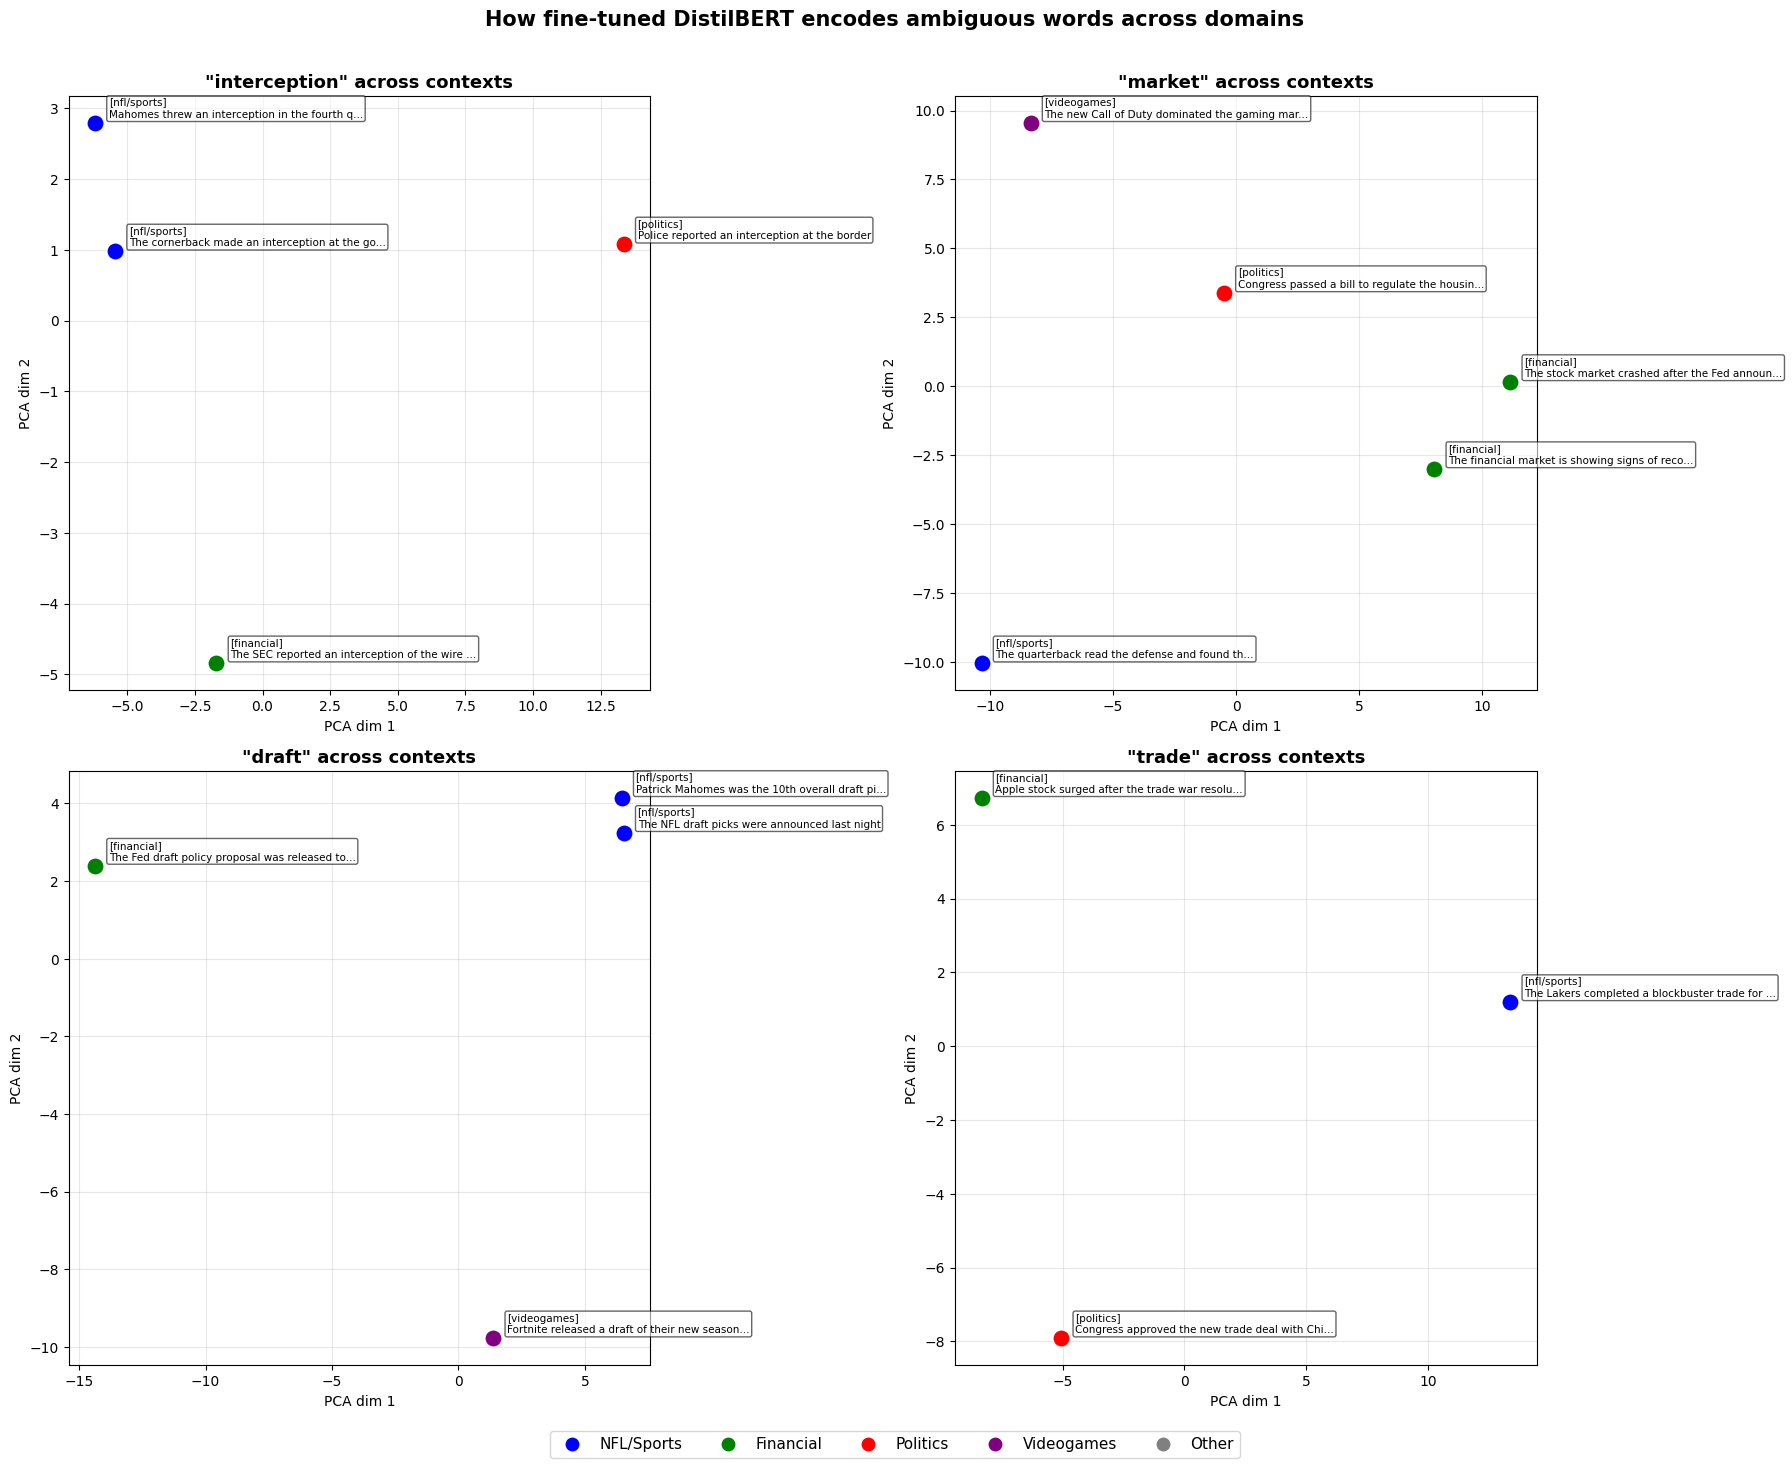

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.lines import Line2D

ambiguous_words = {
    'interception': [
        "Mahomes threw an interception in the fourth quarter",
        "The cornerback made an interception at the goal line",
        "The SEC reported an interception of the wire transfer",
        "Police reported an interception at the border",
    ],
    'market': [
        "The stock market crashed after the Fed announcement",
        "The financial market is showing signs of recovery",
        "The quarterback read the defense and found the open market",
        "The new Call of Duty dominated the gaming market",
        "Congress passed a bill to regulate the housing market",
    ],
    'draft': [
        "The NFL draft picks were announced last night",
        "Patrick Mahomes was the 10th overall draft pick",
        "The Fed draft policy proposal was released today",
        "Congress drafted a new healthcare bill",
        "The game developer drafted new patch notes",
        "Fortnite released a draft of their new season roadmap",
    ],
    'trade': [
        "The Lakers completed a blockbuster trade for the star player",
        "Congress approved the new trade deal with China",
        "Apple stock surged after the trade war resolution",
        "The Madden player traded his star quarterback in franchise mode",
    ]
}

def guess_domain(sentence):
    s = sentence.lower()
    if any(w in s for w in ['mahomes', 'nfl', 'quarterback', 'cornerback',
                              'draft pick', 'lakers', 'player']):
        return 'nfl/sports', 'blue'
    elif any(w in s for w in ['stock', 'fed', 'financial', 'market crash',
                               'trade war', 'apple stock', 'wire transfer']):
        return 'financial', 'green'
    elif any(w in s for w in ['congress', 'sec', 'bill', 'policy', 'police']):
        return 'politics', 'red'
    elif any(w in s for w in ['fortnite', 'call of duty', 'madden',
                               'gaming', 'game developer']):
        return 'videogames', 'purple'
    else:
        return 'other', 'gray'

def get_word_embedding_in_context(sentences, target_word, model, tokenizer, device):
    model.eval()
    embeddings = []
    found_sentences = []

    target_tokens = tokenizer.tokenize(target_word)
    root_token = target_tokens[0]
    print(f"  '{target_word}' tokenizes as: {target_tokens}, matching on root: '{root_token}'")

    for sentence in sentences:
        inputs = tokenizer(sentence, return_tensors='pt',
                          truncation=True, max_length=128).to(device)
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

        target_indices = []
        i = 0
        while i < len(tokens):
            if tokens[i] == root_token:
                span = [i]
                j = i + 1
                while j < len(tokens) and tokens[j].startswith('##'):
                    span.append(j)
                    j += 1
                target_indices = span
                break
            i += 1

        if not target_indices:
            print(f"  Warning: root token '{root_token}' not found in: '{sentence}'")
            print(f"    Tokens were: {tokens}")
            continue

        with torch.no_grad():
            outputs = model.backbone(**inputs)  # was model.distilbert
            hidden_states = outputs.last_hidden_state[0]
            word_embedding = hidden_states[target_indices].mean(dim=0).cpu().numpy()
            embeddings.append(word_embedding)
            found_sentences.append(sentence)

    return np.array(embeddings), found_sentences


# ── Plots ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (word, sentences) in enumerate(ambiguous_words.items()):
    print(f"\nProcessing '{word}'...")
    embeddings, valid_sentences = get_word_embedding_in_context(
        sentences, word, model, tokenizer, device
    )

    if len(embeddings) < 3:
        print(f"  Not enough embeddings for '{word}', skipping")
        continue

    reduced = PCA(n_components=2).fit_transform(embeddings)

    ax = axes[idx]
    for i, (sentence, point) in enumerate(zip(valid_sentences, reduced)):
        domain_label, color = guess_domain(sentence)
        ax.scatter(point[0], point[1], c=color, s=150, zorder=3, edgecolors='white', linewidths=0.8)
        short = sentence[:45] + '...' if len(sentence) > 45 else sentence
        ax.annotate(
            f'[{domain_label}]\n{short}',
            (point[0], point[1]),
            fontsize=7.5,
            xytext=(10, 4),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6)
        )

    ax.set_title(f'"{word}" across contexts', fontsize=13, fontweight='bold')
    ax.set_xlabel('PCA dim 1', fontsize=10)
    ax.set_ylabel('PCA dim 2', fontsize=10)
    ax.grid(True, alpha=0.3)


# ── Cosine similarity tables ───────────────────────────────────────────────────

print("\n=== Cosine similarity: same word, different contexts ===\n")
for word, sentences in ambiguous_words.items():
    embeddings, valid_sentences = get_word_embedding_in_context(
        sentences, word, model, tokenizer, device
    )
    if len(embeddings) < 2:
        continue
    sim_matrix = cosine_similarity(embeddings)
    print(f"'{word}':")
    for i in range(len(valid_sentences)):
        for j in range(i + 1, len(valid_sentences)):
            short_i = valid_sentences[i][:45]
            short_j = valid_sentences[j][:45]
            sim     = sim_matrix[i, j]
            tag     = '  ✓ same domain' if guess_domain(valid_sentences[i])[0] == guess_domain(valid_sentences[j])[0] else ''
            print(f"  {sim:.3f}  |  '{short_i}' vs '{short_j}'{tag}")
    print()


# ── Shared legend ──────────────────────────────────────────────────────────────

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=11, label='NFL/Sports'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=11, label='Financial'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=11, label='Politics'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=11, label='Videogames'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',   markersize=11, label='Other'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle(
    'How fine-tuned DistilBERT encodes ambiguous words across domains',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


Processing 'interception'...
  'interception' tokenizes as: ['interception'], matching on root: 'interception'


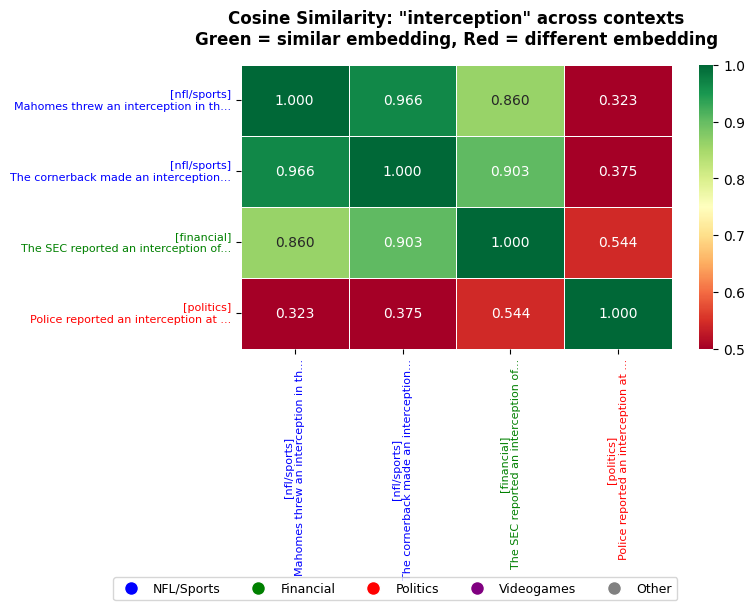


Processing 'market'...
  'market' tokenizes as: ['market'], matching on root: 'market'


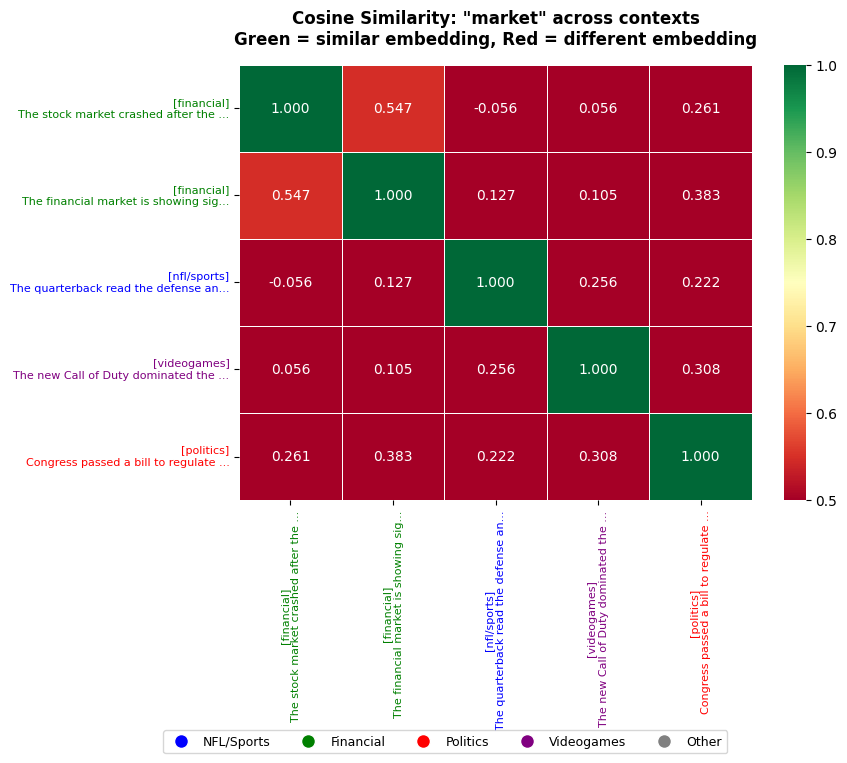


Processing 'draft'...
  'draft' tokenizes as: ['draft'], matching on root: 'draft'
    Tokens were: ['[CLS]', 'congress', 'drafted', 'a', 'new', 'healthcare', 'bill', '[SEP]']
    Tokens were: ['[CLS]', 'the', 'game', 'developer', 'drafted', 'new', 'patch', 'notes', '[SEP]']


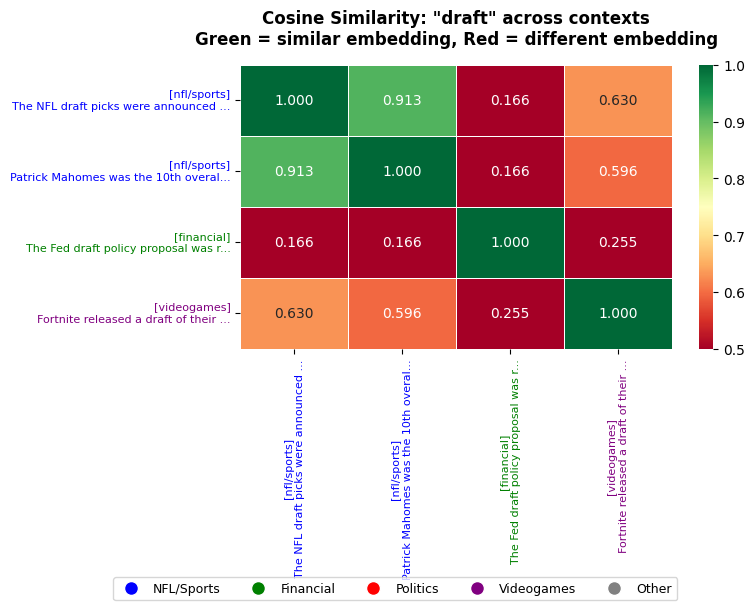


Processing 'trade'...
  'trade' tokenizes as: ['trade'], matching on root: 'trade'
    Tokens were: ['[CLS]', 'the', 'madden', 'player', 'traded', 'his', 'star', 'quarterback', 'in', 'franchise', 'mode', '[SEP]']


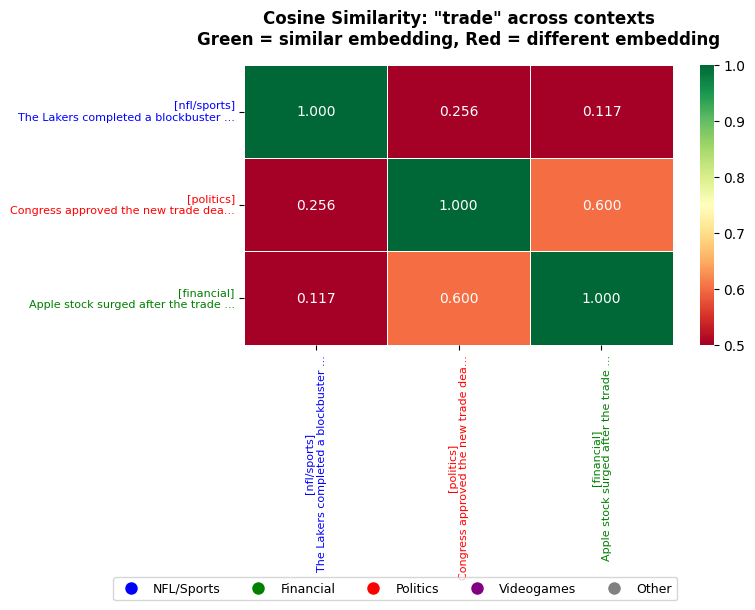

In [94]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

def plot_cosine_heatmap(word, sentences, model, tokenizer, device):
    embeddings, valid_sentences = get_word_embedding_in_context(
        sentences, word, model, tokenizer, device
    )

    if len(embeddings) < 2:
        print(f"Not enough embeddings for '{word}', skipping")
        return

    sim_matrix = cosine_similarity(embeddings)

    # Short labels: domain tag + truncated sentence
    labels = []
    for s in valid_sentences:
        domain_label, _ = guess_domain(s)
        short = s[:35] + '...' if len(s) > 35 else s
        labels.append(f"[{domain_label}]\n{short}")

    # Color the tick labels by domain
    domain_colors = {
        'nfl/sports': 'blue',
        'financial':  'green',
        'politics':   'red',
        'videogames': 'purple',
        'other':      'gray',
    }

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.8), max(6, len(labels) * 1.5)))

    sns.heatmap(
        sim_matrix,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',       # red = dissimilar, green = similar
        vmin=0.5, vmax=1.0,  # cosine sims between contextualized embeddings are usually high
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 10}
    )

    # Color each tick label by its domain
    for tick, sentence in zip(ax.get_xticklabels(), valid_sentences):
        domain_label, color = guess_domain(sentence)
        tick.set_color(color)
        tick.set_fontsize(8)

    for tick, sentence in zip(ax.get_yticklabels(), valid_sentences):
        domain_label, color = guess_domain(sentence)
        tick.set_color(color)
        tick.set_fontsize(8)

    ax.set_title(
        f'Cosine Similarity: "{word}" across contexts\n'
        f'Green = similar embedding, Red = different embedding',
        fontsize=12, fontweight='bold', pad=15
    )

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=10, label='NFL/Sports'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=10, label='Financial'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=10, label='Politics'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=10, label='Videogames'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',   markersize=10, label='Other'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()


# Run for all words
for word, sentences in ambiguous_words.items():
    print(f"\nProcessing '{word}'...")
    plot_cosine_heatmap(word, sentences, model, tokenizer, device)

In [95]:
import torch.nn.functional as F

THRESHOLD = 0.15

def predict(texts, threshold=THRESHOLD):
    if isinstance(texts, str):
        texts = [texts]

    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    results = []
    for i in range(len(texts)):
        domain_probs    = F.softmax(outputs['domain_logits'][i],    dim=-1)
        sentiment_probs = F.softmax(outputs['sentiment_logits'][i], dim=-1)

        domains = [id2domain[j] for j, p in enumerate(domain_probs) if p.item() > threshold] or ['unknown']

        results.append({
            'text':            texts[i],
            'domains':         domains,
            'domain_scores':   {id2domain[j]: round(p.item(), 3) for j, p in enumerate(domain_probs)},
            'sentiment':       id2sentiment[sentiment_probs.argmax().item()],
            'sentiment_score': round(sentiment_probs.max().item(), 3),
        })

    return results


texts = [
    "bank investment",
    "$NVDA crashed 12% on AI demand fears, dragging the S&P 500 into a 2% selloff and triggering circuit breakers across the tech sector.",
    "$NVDA fell 2% amid AI sector rotation, with the S&P 500 seeing modest declines on above-average volume.",
]

for r in predict(texts):
    print(f"Text:      {r['text']}")
    print(f"Domains:   {r['domains']}")
    print(f"Sentiment: {r['sentiment']} ({r['sentiment_score']})")
    print(f"Scores:    {r['domain_scores']}\n")

Text:      bank investment
Domains:   ['financial', 'politics']
Sentiment: neutral (0.666)
Scores:    {'nfl': 0.025, 'financial': 0.288, 'politics': 0.535, 'videogames': 0.073, 'none': 0.08}

Text:      $NVDA crashed 12% on AI demand fears, dragging the S&P 500 into a 2% selloff and triggering circuit breakers across the tech sector.
Domains:   ['financial']
Sentiment: negative (0.989)
Scores:    {'nfl': 0.003, 'financial': 0.98, 'politics': 0.002, 'videogames': 0.013, 'none': 0.002}

Text:      $NVDA fell 2% amid AI sector rotation, with the S&P 500 seeing modest declines on above-average volume.
Domains:   ['financial']
Sentiment: negative (0.939)
Scores:    {'nfl': 0.001, 'financial': 0.984, 'politics': 0.006, 'videogames': 0.005, 'none': 0.003}

